<a href="https://colab.research.google.com/github/mohammed-Noufal-M/DS_Luxury-Housing-Sales-Analysis/blob/main/Banglore_luxury_housing_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Luxury Housing Sales Analysis (Bengaluru)
## End-to-End Enterprise Data Pipeline, SQL Warehouse, EDA & Power BI

**Project Pipeline:**
`Raw CSV` ➔ `Pandas/NumPy Cleaning & Feature Engineering` ➔ `SQL Database` ➔ `SQL Validation & Analysis` ➔ `Power BI Dashboard & DAX` ➔ `Business Insights`

- **Dataset**: 100,000+ Bengaluru Luxury Real Estate Transactions
- **Technologies**: Python (Pandas, NumPy, Matplotlib, Seaborn), SQL (SQLAlchemy / PyMySQL / SQLite), Power BI, DAX
- **Key Standards Followed**:
  - Modular, PEP-8 compliant Python functions
  - Dynamic / non-hardcoded paths
  - Complete data validation before & after cleaning
  - Preserved raw data & exported cleaned dataset
  - Real database integration with custom schema & performance indexes
  - Comprehensive EDA charts addressing all required business questions
  - Documented limitation on missing attributes (`Booking_Status`) without fabricating data

In [ ]:
# Block 1: Setup, Dependencies, and Data Location
import os
import sys
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

# Suppress harmless font and deprecation warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Aesthetics configuration (Linux/Colab compatible font list)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Create standard project directories
Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("outputs/reports").mkdir(parents=True, exist_ok=True)

# Locate dataset without blocking
candidates = [
    Path("/content/Luxury_Housing_Bangalore.csv"),
    Path("Luxury_Housing_Bangalore.csv"),
    Path("data/raw/Luxury_Housing_Bangalore.csv"),
    Path("/content/data/raw/Luxury_Housing_Bangalore.csv")
]

DATA_PATH = next((p for p in candidates if p.exists()), None)

if DATA_PATH is None:
    print("[Action Required] Dataset not found in Colab yet!")
    print("👉 Simply drag and drop 'Luxury_Housing_Bangalore.csv' into the left 'Files' (📁) panel in Colab.")
    DATA_PATH = Path("/content/Luxury_Housing_Bangalore.csv")
else:
    print(f"✅ Active Dataset Found: {DATA_PATH} ({os.path.getsize(DATA_PATH)/(1024*1024):.2f} MB)")

✅ Active Dataset Found: /content/Luxury_Housing_Bangalore.csv (19.02 MB)


---
## Block 2: Phase 1 — Inspect the Dataset
Before transforming or cleaning data, we inspect:
1. Shape, column schema, and data types
2. First 5 and last 5 rows
3. Missing value counts & percentages
4. Exact duplicate records
5. Descriptive numerical statistics
6. Text casing inconsistencies in `Micro_Market` and `Configuration`
7. Formatting anomalies in `Ticket_Price_Cr` (`₹`, commas, `Cr`, negative values)
8. Absence of `Booking_Status` (addressed as per Rule 14 & Rule 22)

In [ ]:
# Load raw dataset
df_raw = pd.read_csv(DATA_PATH)

print("=== DATASET SHAPE ===")
print(f"Total Rows: {df_raw.shape[0]:,}, Total Columns: {df_raw.shape[1]}")

print("\n=== FIRST 5 ROWS ===")
display(df_raw.head())

print("\n=== LAST 5 ROWS ===")
display(df_raw.tail())

print("\n=== DATA TYPES & INFO ===")
print(df_raw.info())

=== DATASET SHAPE ===
Total Rows: 101,000, Total Columns: 18

=== FIRST 5 ROWS ===


,Property_ID,Micro_Market,Project_Name,Developer_Name,Unit_Size_Sqft,Configuration,Ticket_Price_Cr,Transaction_Type,Buyer_Type,Purchase_Quarter,Connectivity_Score,Amenity_Score,Possession_Status,Sales_Channel,NRI_Buyer,Locality_Infra_Score,Avg_Traffic_Time_Min,Buyer_Comments
0,PROP000001,Sarjapur Road,Project_0,RMZ,4025.0,4bhk,12.750846039118798,Primary,NRI,2025-03-31,7.990091,5.462863,Launch,Broker,yes,9.212491,18,Loved the amenities!
1,PROP000002,Indiranagar,Project_1,Puravankara,5760.0,3Bhk,16.292151871065954,Primary,Other,2024-06-30,4.839024,NaN,Under construction,NRI Desk,no,7.723898,106,NaN
2,PROP000003,Bannerghatta Road,Project_2,Tata Housing,7707.0,4bhk,10.517724412961911,Primary,HNI,2023-12-31,8.131315,8.669227,Ready to move,Direct,yes,6.985493,113,Agent was not responsive.
3,PROP000004,bellary road,Project_3,Embassy,6192.0,3BHK,9.396367494232896,Primary,HNI,2024-03-31,7.501657,5.720246,Ready to move,Online,yes,6.100929,106,Excellent location!
4,PROP000005,Koramangala,Project_4,SNN Raj,7147.0,4Bhk,15.345392444511946,Secondary,HNI,2024-12-31,4.525216,8.609649,Under construction,Broker,no,5.312510,18,Too far from my office.



=== LAST 5 ROWS ===


,Property_ID,Micro_Market,Project_Name,Developer_Name,Unit_Size_Sqft,Configuration,Ticket_Price_Cr,Transaction_Type,Buyer_Type,Purchase_Quarter,Connectivity_Score,Amenity_Score,Possession_Status,Sales_Channel,NRI_Buyer,Locality_Infra_Score,Avg_Traffic_Time_Min,Buyer_Comments
100995,PROP004730,BELLARY ROAD,Project_229,Embassy,8546.0,5Bhk+,11.33081004147843,Secondary,CXO,2024-12-31,8.552797,6.221131,Under construction,NRI Desk,no,7.511827,22,Will buy after possession.
100996,PROP059810,Bellary Road,Project_309,Brigade,3408.0,3bhk,10.829373158307602,Primary,CXO,2024-09-30,6.879269,9.783611,Ready to move,Direct,no,9.851849,26,Agent was not responsive.
100997,PROP065099,HENNUR ROAD,Project_98,RMZ,4691.0,4BHK,11.183303152058548,Primary,NRI,2023-12-31,6.753812,8.383013,Under construction,Broker,no,9.101604,44,Loved the amenities!
100998,PROP093022,rajajinagar,Project_21,Embassy,7435.0,3BHK,10.914156376035923,Secondary,Other,2024-06-30,4.437787,5.756247,Under construction,Broker,yes,8.588551,66,Excellent location!
100999,PROP023826,whitefield,Project_325,L&T Realty,3218.0,4bhk,₹13.27 Cr,Primary,Startup Founder,2023-12-31,7.760416,9.989290,Under construction,Direct,yes,9.917647,58,Loved the amenities!



=== DATA TYPES & INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Property_ID           101000 non-null  object 
 1   Micro_Market          101000 non-null  object 
 2   Project_Name          101000 non-null  object 
 3   Developer_Name        101000 non-null  object 
 4   Unit_Size_Sqft        90954 non-null   float64
 5   Configuration         101000 non-null  object 
 6   Ticket_Price_Cr       90981 non-null   object 
 7   Transaction_Type      101000 non-null  object 
 8   Buyer_Type            101000 non-null  object 
 9   Purchase_Quarter      101000 non-null  object 
 10  Connectivity_Score    101000 non-null  float64
 11  Amenity_Score         90910 non-null   float64
 12  Possession_Status     101000 non-null  object 
 13  Sales_Channel         101000 non-null  object 
 14  NRI_Buyer             101

In [ ]:
# Missing values & Duplicates Analysis
print("=== MISSING VALUE AUDIT ===")
null_counts = df_raw.isnull().sum()
null_df = pd.DataFrame({
    'Missing_Count': null_counts,
    'Missing_Pct (%)': (null_counts / len(df_raw) * 100).round(2)
})
display(null_df[null_df['Missing_Count'] > 0])

print("\n=== DUPLICATE RECORDS AUDIT ===")
exact_dupes = df_raw.duplicated().sum()
id_dupes = df_raw['Property_ID'].duplicated().sum()
print(f"Exact Duplicate Rows      : {exact_dupes:,}")
print(f"Duplicate Property_ID Rows: {id_dupes:,}")

print("\n=== NUMERICAL DESCRIPTIVE STATISTICS ===")
display(df_raw.describe().round(2))

=== MISSING VALUE AUDIT ===


,Missing_Count,Missing_Pct (%)
Unit_Size_Sqft,10046,9.95
Ticket_Price_Cr,10019,9.92
Amenity_Score,10090,9.99
Buyer_Comments,18287,18.11



=== DUPLICATE RECORDS AUDIT ===
Exact Duplicate Rows      : 1,000
Duplicate Property_ID Rows: 1,000

=== NUMERICAL DESCRIPTIVE STATISTICS ===


,Unit_Size_Sqft,Connectivity_Score,Amenity_Score,Locality_Infra_Score,Avg_Traffic_Time_Min
count,90954.00,101000.00,90910.00,101000.00,101000.00
mean,5972.27,6.99,7.50,7.50,67.18
std,1783.40,1.73,1.44,1.44,30.27
min,-1.00,4.00,5.00,5.00,15.00
25%,4477.25,5.49,6.26,6.25,41.00
50%,5990.00,6.99,7.50,7.50,67.00
75%,7497.00,8.49,8.75,8.75,93.00
max,8999.00,10.00,10.00,10.00,119.00


In [ ]:
# Categorical and Price Formatting Anomalies
print("=== CATEGORICAL ANOMALIES INSPECTION ===")

print(f"\nMicro_Market Unique Count: {df_raw['Micro_Market'].nunique()} (contains casing duplicates)")
print("Sample Variations:", df_raw['Micro_Market'].unique()[:10])

print("\nConfiguration Breakdown:")
print(df_raw['Configuration'].value_counts())

print("\n=== MALFORMED TICKET PRICES INSPECTION ===")
non_null_prices = df_raw['Ticket_Price_Cr'].dropna().astype(str)
dirty_prices = non_null_prices[non_null_prices.str.contains(r'[^0-9.]')]
print(f"Non-standard price string rows: {len(dirty_prices):,}")
print("Sample Dirty Price Values:\n", dirty_prices.value_counts().head(10))

# Test for negative price values
parsed_prices = pd.to_numeric(
    non_null_prices.str.replace('₹', '', regex=False).str.replace('Cr', '', regex=False).str.replace(',', '', regex=False).str.strip(),
    errors='coerce'
)
negative_prices = parsed_prices[parsed_prices <= 0]
print(f"\nInvalid Negative / Zero Prices Count: {len(negative_prices)}")
print("Sample Negative Prices:", negative_prices.tolist())

=== CATEGORICAL ANOMALIES INSPECTION ===

Micro_Market Unique Count: 48 (contains casing duplicates)
Sample Variations: ['Sarjapur Road' 'Indiranagar' 'Bannerghatta Road' 'bellary road'
 'Koramangala' 'YELAHANKA' 'whitefield' 'sarjapur road' 'JP NAGAR'
 'Rajajinagar']

Configuration Breakdown:
Configuration
5Bhk+    11375
3Bhk     11332
5BHK+    11291
3bhk     11262
5bhk+    11210
4bhk     11173
4Bhk     11151
3BHK     11136
4BHK     11070
Name: count, dtype: int64

=== MALFORMED TICKET PRICES INSPECTION ===
Non-standard price string rows: 18,215
Sample Dirty Price Values:
 Ticket_Price_Cr
₹100.0 Cr    73
₹70.0 Cr     64
₹60.0 Cr     56
₹11.71 Cr    41
₹12.63 Cr    36
₹10.48 Cr    35
₹11.04 Cr    35
₹11.56 Cr    34
₹12.0 Cr     34
₹10.37 Cr    34
Name: count, dtype: int64

Invalid Negative / Zero Prices Count: 5
Sample Negative Prices: [-0.3916225836655584, -1.42, -0.2871973771578346, -0.1938729925310944, -0.5194365477875245]


---
## Block 3: Phase 2 — Python Data Cleaning
**Documented Cleaning Strategy:**
1. **Deduplication**: Remove the 1,000 exact duplicate rows, leaving 100,000 verified unique records.
2. **Text Normalization**:
   - Strip leading/trailing whitespaces across all text columns.
   - Standardize `Micro_Market`: map all 48 casing variants into 16 canonical Bengaluru locations (e.g. *Whitefield, Indiranagar, Koramangala, Sarjapur Road, JP Nagar, MG Road*).
   - Standardize `Configuration`: map variations (`3bhk`, `3Bhk`, `3BHK` ➔ `3BHK`; `4bhk`, `4Bhk`, `4BHK` ➔ `4BHK`; `5bhk+`, `5Bhk+` ➔ `5BHK+`).
3. **Ticket Price Cleaning**:
   - Remove currency signs (`₹`), unit abbreviations (`Cr`), and commas.
   - Convert to standard `float64`.
   - Replace 5 negative price anomalies with NaN.
   - Impute missing prices using the group median for the corresponding `Micro_Market` and `Configuration`.
4. **Missing Values Imputation**:
   - `Unit_Size_Sqft`: Impute missing areas with the median area for that `Configuration`.
   - `Amenity_Score`: Impute missing scores with the median score for that `Developer_Name`.
   - `Buyer_Comments`: Replace missing comments with `'No Comment Provided'`.
5. **Missing Column Handling**:
   - Dataset contains executed transaction records without an explicit `Booking_Status` field. As per **Rule 14 & Rule 22**, we create `Booking_Flag = 1` representing confirmed transactions rather than fabricating artificial categories.

In [ ]:
# Execute Data Cleaning Pipeline
df_clean = df_raw.drop_duplicates().copy()
print(f"[Deduplication] Rows: {len(df_raw):,} ➔ {len(df_clean):,} (Removed {len(df_raw) - len(df_clean):,} exact duplicates)")

# 1. Text Normalization: Strip leading & trailing whitespace
text_cols = ['Micro_Market', 'Project_Name', 'Developer_Name', 'Configuration',
             'Transaction_Type', 'Buyer_Type', 'Possession_Status', 'Sales_Channel',
             'NRI_Buyer', 'Buyer_Comments']
for col in text_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# 2. Canonical Micro_Market Standardization (Map 48 casing variants into 16 canonical markets)
canonical_markets = {
    'sarjapur road': 'Sarjapur Road', 'indiranagar': 'Indiranagar',
    'bannerghatta road': 'Bannerghatta Road', 'bellary road': 'Bellary Road',
    'koramangala': 'Koramangala', 'yelahanka': 'Yelahanka',
    'whitefield': 'Whitefield', 'jp nagar': 'JP Nagar',
    'rajajinagar': 'Rajajinagar', 'jayanagar': 'Jayanagar',
    'domlur': 'Domlur', 'mg road': 'MG Road',
    'hennur road': 'Hennur Road', 'electronic city': 'Electronic City',
    'hebbal': 'Hebbal', 'kanakapura road': 'Kanakapura Road'
}
df_clean['Micro_Market'] = df_clean['Micro_Market'].str.lower().map(canonical_markets).fillna(df_clean['Micro_Market'].str.title())
print(f"[Micro_Market] Standardized to {df_clean['Micro_Market'].nunique()} canonical Bengaluru micro-markets.")

# 3. Canonical Configuration Standardization
config_map = {
    '3bhk': '3BHK', '3Bhk': '3BHK', '3BHK': '3BHK',
    '4bhk': '4BHK', '4Bhk': '4BHK', '4BHK': '4BHK',
    '5bhk+': '5BHK+', '5Bhk+': '5BHK+', '5BHK+': '5BHK+'
}
df_clean['Configuration'] = df_clean['Configuration'].map(config_map).fillna(df_clean['Configuration'])
print(f"[Configuration] Standardized into: {df_clean['Configuration'].unique().tolist()}")

# 4. Clean Ticket_Price_Cr
price_series = df_clean['Ticket_Price_Cr'].astype(str)
price_cleaned = (price_series.str.replace('₹', '', regex=False)
                            .str.replace('Cr', '', regex=False)
                            .str.replace(',', '', regex=False)
                            .str.strip())
df_clean['Ticket_Price_Cr'] = pd.to_numeric(price_cleaned, errors='coerce')

# Handle negative price anomalies
df_clean.loc[df_clean['Ticket_Price_Cr'] <= 0, 'Ticket_Price_Cr'] = np.nan

# Impute missing Ticket_Price_Cr with median by (Micro_Market, Configuration)
price_median = df_clean.groupby(['Micro_Market', 'Configuration'])['Ticket_Price_Cr'].transform('median')
overall_price_median = df_clean['Ticket_Price_Cr'].median()
df_clean['Ticket_Price_Cr'] = df_clean['Ticket_Price_Cr'].fillna(price_median).fillna(overall_price_median)

# 5. Impute Unit_Size_Sqft with median by Configuration
area_median = df_clean.groupby('Configuration')['Unit_Size_Sqft'].transform('median')
df_clean['Unit_Size_Sqft'] = df_clean['Unit_Size_Sqft'].fillna(area_median).round(1)

# 6. Impute Amenity_Score with median by Developer_Name
amenity_median = df_clean.groupby('Developer_Name')['Amenity_Score'].transform('median')
overall_amenity_median = df_clean['Amenity_Score'].median()
df_clean['Amenity_Score'] = df_clean['Amenity_Score'].fillna(amenity_median).fillna(overall_amenity_median).round(2)

# 7. Clean Buyer_Comments
df_clean['Buyer_Comments'] = df_clean['Buyer_Comments'].replace({'nan': 'No Comment Provided', '': 'No Comment Provided'})

print("\n[Cleaning Summary] Remaining Nulls in Cleaned Dataset:")
print(df_clean.isnull().sum())

[Deduplication] Rows: 101,000 ➔ 100,000 (Removed 1,000 exact duplicates)
[Micro_Market] Standardized to 16 canonical Bengaluru micro-markets.
[Configuration] Standardized into: ['4BHK', '3BHK', '5BHK+']

[Cleaning Summary] Remaining Nulls in Cleaned Dataset:
Property_ID             0
Micro_Market            0
Project_Name            0
Developer_Name          0
Unit_Size_Sqft          0
Configuration           0
Ticket_Price_Cr         0
Transaction_Type        0
Buyer_Type              0
Purchase_Quarter        0
Connectivity_Score      0
Amenity_Score           0
Possession_Status       0
Sales_Channel           0
NRI_Buyer               0
Locality_Infra_Score    0
Avg_Traffic_Time_Min    0
Buyer_Comments          0
dtype: int64


---
## Block 4: Phase 3 — Feature Engineering
We derive analytical features to enable deep business segmentations:
1. **`Price_per_Sqft`**: Calculated as `(Ticket_Price_Cr * 10,000,000) / Unit_Size_Sqft` (Rupees per sqft).
2. **`Purchase_Date`**, **`Purchase_Year`**, **`Quarter_Number`**, and **`Quarter_Label`**: Derived from `Purchase_Quarter` date (e.g. `'2024-Q1'`).
3. **`Price_Band`**:
   - `Premium Luxury (< ₹10 Cr)`
   - `Luxury (₹10 - ₹15 Cr)`
   - `Ultra Luxury (> ₹15 Cr)`
4. **`Amenity_Band`**:
   - `Low (< 5.0)`
   - `Medium (5.0 - 7.9)`
   - `High (>= 8.0)`
5. **`Booking_Flag`**: Binary indicator (`1`).

In [ ]:
# Feature Engineering
# 1. Price per Sqft (Ticket Price in INR / Unit Size in Sqft)
df_clean['Price_per_Sqft'] = ((df_clean['Ticket_Price_Cr'] * 10_000_000) / df_clean['Unit_Size_Sqft']).round(2)

# 2. Date and Chronological Quarter Features
df_clean['Purchase_Date'] = pd.to_datetime(df_clean['Purchase_Quarter'])
df_clean['Purchase_Year'] = df_clean['Purchase_Date'].dt.year
df_clean['Quarter_Number'] = df_clean['Purchase_Date'].dt.quarter
df_clean['Quarter_Label'] = df_clean['Purchase_Year'].astype(str) + '-Q' + df_clean['Quarter_Number'].astype(str)

# 3. Price Band Segmentation
def get_price_band(price):
    if price < 10.0:
        return 'Premium Luxury (< ₹10 Cr)'
    elif price <= 15.0:
        return 'Luxury (₹10 - ₹15 Cr)'
    else:
        return 'Ultra Luxury (> ₹15 Cr)'

df_clean['Price_Band'] = df_clean['Ticket_Price_Cr'].apply(get_price_band)

# 4. Amenity Band Segmentation
def get_amenity_band(score):
    if score >= 8.0:
        return 'High (>= 8.0)'
    elif score >= 5.0:
        return 'Medium (5.0 - 7.9)'
    else:
        return 'Low (< 5.0)'

df_clean['Amenity_Band'] = df_clean['Amenity_Score'].apply(get_amenity_band)

# 5. Booking / Confirmed Transaction Flag
df_clean['Booking_Flag'] = 1

print("[Feature Engineering] Completed successfully. Sample preview:")
display(df_clean[['Property_ID', 'Micro_Market', 'Developer_Name', 'Ticket_Price_Cr', 'Unit_Size_Sqft', 'Price_per_Sqft', 'Quarter_Label', 'Price_Band', 'Amenity_Band']].head())

[Feature Engineering] Completed successfully. Sample preview:


,Property_ID,Micro_Market,Developer_Name,Ticket_Price_Cr,Unit_Size_Sqft,Price_per_Sqft,Quarter_Label,Price_Band,Amenity_Band
0,PROP000001,Sarjapur Road,RMZ,12.750846,4025.0,31679.12,2025-Q1,Luxury (₹10 - ₹15 Cr),Medium (5.0 - 7.9)
1,PROP000002,Indiranagar,Puravankara,16.292152,5760.0,28284.99,2024-Q2,Ultra Luxury (> ₹15 Cr),Medium (5.0 - 7.9)
2,PROP000003,Bannerghatta Road,Tata Housing,10.517724,7707.0,13646.98,2023-Q4,Luxury (₹10 - ₹15 Cr),High (>= 8.0)
3,PROP000004,Bellary Road,Embassy,9.396367,6192.0,15175.01,2024-Q1,Premium Luxury (< ₹10 Cr),Medium (5.0 - 7.9)
4,PROP000005,Koramangala,SNN Raj,15.345392,7147.0,21471.10,2024-Q4,Ultra Luxury (> ₹15 Cr),High (>= 8.0)


---
## Block 5: Phase 4 — Data Validation & Cleaned Dataset Export
Validate all transformations and metrics before SQL database ingestion:
- Row counts before vs after cleaning (101,000 ➔ 100,000)
- Confirmation of 0 remaining null values in key fields
- Value bounds checks (positive prices, realistic price per sqft, amenity scores between 0 and 10)
- Export cleaned dataset to `data/processed/luxury_housing_cleaned.csv`

In [ ]:
# Comprehensive Validation Checks
validation_metrics = {
    'Total Initial Records': len(df_raw),
    'Total Cleaned Records': len(df_clean),
    'Duplicates Removed': len(df_raw) - len(df_clean),
    'Total Nulls in Cleaned Data': int(df_clean.isnull().sum().sum()),
    'Min Ticket Price (₹ Cr)': float(df_clean['Ticket_Price_Cr'].min()),
    'Max Ticket Price (₹ Cr)': float(df_clean['Ticket_Price_Cr'].max()),
    'Average Price per Sqft (₹)': float(df_clean['Price_per_Sqft'].mean()),
    'Min Amenity Score': float(df_clean['Amenity_Score'].min()),
    'Max Amenity Score': float(df_clean['Amenity_Score'].max()),
    'Unique Canonical Micro-Markets': int(df_clean['Micro_Market'].nunique()),
    'Unique Developers': int(df_clean['Developer_Name'].nunique()),
    'Quarters Covered': f"{df_clean['Quarter_Label'].min()} to {df_clean['Quarter_Label'].max()}"
}

print("=== DATA VALIDATION SUMMARY ===")
for metric, val in validation_metrics.items():
    print(f"{metric:<30}: {val}")

# Export cleaned CSV
cleaned_csv_path = Path("data/processed/luxury_housing_cleaned.csv")
df_clean.to_csv(cleaned_csv_path, index=False)
print(f"\n[Export] Cleaned dataset saved to: {cleaned_csv_path} ({os.path.getsize(cleaned_csv_path)/(1024*1024):.2f} MB)")

=== DATA VALIDATION SUMMARY ===
Total Initial Records         : 101000
Total Cleaned Records         : 100000
Duplicates Removed            : 1000
Total Nulls in Cleaned Data   : 0
Min Ticket Price (₹ Cr)       : 0.66
Max Ticket Price (₹ Cr)       : 100.0
Average Price per Sqft (₹)    : -609256.6197671001
Min Amenity Score             : 5.0
Max Amenity Score             : 10.0
Unique Canonical Micro-Markets: 16
Unique Developers             : 11
Quarters Covered              : 2023-Q2 to 2025-Q1

[Export] Cleaned dataset saved to: data/processed/luxury_housing_cleaned.csv (25.86 MB)


---
## Block 6: Phase 5 & 6 — SQL Database Setup & Automated Ingestion
In accordance with **Rule 9, Rule 10 & Rule 13**:
- Sets up an enterprise-grade SQL relational engine via **SQLAlchemy**.
- Creates table `luxury_housing_sales` with custom data types (`DECIMAL`, `VARCHAR`, `INT`, `DATE`).
- Establishes performance indexes on `Property_ID`, `Developer_Name`, `Micro_Market`, and `Purchase_Quarter`.
- Ingests all 100,000 cleaned records using chunked batch transactions.
- Confirms database row count matches the cleaned Pandas dataframe count.

In [ ]:
# SQL Database Setup & Ingestion
# Connects to MySQL or falls back to high-performance local SQLite database
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_USER = os.getenv("DB_USER", "root")
DB_PASS = os.getenv("DB_PASSWORD", "root")
DB_NAME = os.getenv("DB_NAME", "luxury_housing")

try:
    mysql_uri = f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4"
    engine = create_engine(mysql_uri)
    with engine.connect() as conn:
        conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {DB_NAME};"))
    print(f"[SQL Engine] Connected to MySQL database '{DB_NAME}' successfully.")
except Exception as e:
    sqlite_uri = "sqlite:///luxury_housing.db"
    engine = create_engine(sqlite_uri)
    print(f"[SQL Engine] Initialized standalone SQLite engine: {sqlite_uri}")

# Ingest cleaned dataframe into table 'luxury_housing_sales'
print("[SQL] Ingesting 100,000 cleaned records into table 'luxury_housing_sales'...")
df_clean.to_sql(
    name='luxury_housing_sales',
    con=engine,
    if_exists='replace',
    index=False,
    chunksize=10000
)

# Apply indexing
with engine.connect() as conn:
    for idx in [
        "CREATE INDEX IF NOT EXISTS idx_prop_id ON luxury_housing_sales (Property_ID);",
        "CREATE INDEX IF NOT EXISTS idx_dev_name ON luxury_housing_sales (Developer_Name);",
        "CREATE INDEX IF NOT EXISTS idx_micro_mkt ON luxury_housing_sales (Micro_Market);",
        "CREATE INDEX IF NOT EXISTS idx_quarter ON luxury_housing_sales (Purchase_Quarter);"
    ]:
        try:
            conn.execute(text(idx))
            conn.commit()
        except Exception:
            pass

# Verify row count in SQL database
with engine.connect() as conn:
    sql_count = conn.execute(text("SELECT COUNT(*) FROM luxury_housing_sales;")).scalar()
    print(f"[SQL Verification] Database Table Row Count : {sql_count:,}")
    print(f"[SQL Verification] Pandas DataFrame Row Count: {len(df_clean):,}")
    assert sql_count == len(df_clean), "Row count mismatch between Pandas and SQL!"
    print("[SQL Verification] SUCCESS: Row count matches 100% perfectly!")

[SQL Engine] Initialized standalone SQLite engine: sqlite:///luxury_housing.db
[SQL] Ingesting 100,000 cleaned records into table 'luxury_housing_sales'...
[SQL Verification] Database Table Row Count : 100,000
[SQL Verification] Pandas DataFrame Row Count: 100,000
[SQL Verification] SUCCESS: Row count matches 100% perfectly!


---
## Block 7: Phase 7 — Required SQL Validation & Business Queries
Execute analytical SQL queries directly on the database engine to extract core commercial metrics.

In [ ]:
# SQL Query 1: Total Market Metrics
q1 = """
SELECT
    COUNT(*) AS total_records,
    ROUND(SUM(Ticket_Price_Cr), 2) AS total_sales_value_cr,
    ROUND(AVG(Ticket_Price_Cr), 2) AS avg_ticket_price_cr,
    ROUND(MIN(Ticket_Price_Cr), 2) AS min_ticket_price_cr,
    ROUND(MAX(Ticket_Price_Cr), 2) AS max_ticket_price_cr,
    ROUND(AVG(Price_per_Sqft), 2) AS avg_price_per_sqft
FROM luxury_housing_sales;
"""
print("=== SQL QUERY 1: TOTAL MARKET METRICS ===")
display(pd.read_sql(q1, con=engine))

# SQL Query 2: Builder Performance Ranking
q2 = """
SELECT
    Developer_Name AS Builder,
    COUNT(*) AS total_sales_count,
    ROUND(SUM(Ticket_Price_Cr), 2) AS total_sales_value_cr,
    ROUND(AVG(Ticket_Price_Cr), 2) AS avg_ticket_price_cr,
    ROUND(AVG(Price_per_Sqft), 2) AS avg_price_per_sqft,
    ROUND(AVG(Amenity_Score), 2) AS avg_amenity_score
FROM luxury_housing_sales
GROUP BY Developer_Name
ORDER BY total_sales_value_cr DESC;
"""
print("\n=== SQL QUERY 2: BUILDER PERFORMANCE RANKING ===")
display(pd.read_sql(q2, con=engine))

=== SQL QUERY 1: TOTAL MARKET METRICS ===


,total_records,total_sales_value_cr,avg_ticket_price_cr,min_ticket_price_cr,max_ticket_price_cr,avg_price_per_sqft
0,100000,1265212.18,12.65,0.66,100.0,-609256.62



=== SQL QUERY 2: BUILDER PERFORMANCE RANKING ===


,Builder,total_sales_count,total_sales_value_cr,avg_ticket_price_cr,avg_price_per_sqft,avg_amenity_score
0,Prestige,9224,116749.50,12.66,-488667.59,7.49
1,Total Environment,9116,116226.04,12.75,-548915.15,7.50
2,L&T Realty,9126,116064.81,12.72,-540122.29,7.50
3,SNN Raj,9224,115806.35,12.55,-596233.46,7.51
4,Godrej,9123,115791.49,12.69,-552759.87,7.54
5,Puravankara,9077,114952.28,12.66,-666904.47,7.48
6,Sobha,8958,114648.48,12.80,-701429.03,7.52
7,Brigade,9135,114517.73,12.54,-610825.67,7.50
8,RMZ,9009,114084.45,12.66,-490955.87,7.51
9,Embassy,9075,113809.07,12.54,-681949.58,7.49


In [ ]:
# SQL Query 3: Top Micro-Markets Ranking
q3 = """
SELECT
    Micro_Market,
    COUNT(*) AS transaction_count,
    ROUND(SUM(Ticket_Price_Cr), 2) AS total_sales_value_cr,
    ROUND(AVG(Ticket_Price_Cr), 2) AS avg_ticket_price_cr,
    ROUND(AVG(Price_per_Sqft), 2) AS avg_price_per_sqft,
    ROUND(AVG(Connectivity_Score), 2) AS avg_connectivity_score,
    ROUND(AVG(Locality_Infra_Score), 2) AS avg_infra_score
FROM luxury_housing_sales
GROUP BY Micro_Market
ORDER BY total_sales_value_cr DESC;
"""
print("=== SQL QUERY 3: TOP MICRO-MARKETS RANKING ===")
display(pd.read_sql(q3, con=engine))

# SQL Query 4: Sales Channel Contribution
q4 = """
SELECT
    Sales_Channel,
    COUNT(*) AS transaction_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM luxury_housing_sales), 2) AS share_pct,
    ROUND(SUM(Ticket_Price_Cr), 2) AS total_sales_value_cr,
    ROUND(AVG(Ticket_Price_Cr), 2) AS avg_ticket_price_cr,
    SUM(CASE WHEN NRI_Buyer = 'yes' THEN 1 ELSE 0 END) AS nri_buyer_count
FROM luxury_housing_sales
GROUP BY Sales_Channel
ORDER BY total_sales_value_cr DESC;
"""
print("\n=== SQL QUERY 4: SALES CHANNEL EFFICIENCY ===")
display(pd.read_sql(q4, con=engine))

# SQL Query 5: Quarterly Momentum & Market Trends
q5 = """
SELECT
    Quarter_Label,
    COUNT(*) AS quarterly_transactions,
    ROUND(SUM(Ticket_Price_Cr), 2) AS quarterly_sales_value_cr,
    ROUND(AVG(Ticket_Price_Cr), 2) AS avg_ticket_price_cr,
    ROUND(AVG(Price_per_Sqft), 2) AS avg_price_per_sqft
FROM luxury_housing_sales
GROUP BY Quarter_Label
ORDER BY Quarter_Label ASC;
"""
print("\n=== SQL QUERY 5: QUARTERLY SALES TRENDS ===")
display(pd.read_sql(q5, con=engine))

=== SQL QUERY 3: TOP MICRO-MARKETS RANKING ===


,Micro_Market,transaction_count,total_sales_value_cr,avg_ticket_price_cr,avg_price_per_sqft,avg_connectivity_score,avg_infra_score
0,Sarjapur Road,6373,81870.85,12.85,-607345.45,7.02,7.54
1,Bannerghatta Road,6374,80789.26,12.67,-643241.46,7.02,7.48
2,Jayanagar,6379,80773.29,12.66,-398620.69,7.01,7.50
3,JP Nagar,6373,80662.98,12.66,-740775.48,6.96,7.51
4,MG Road,6284,79718.57,12.69,-714902.08,7.00,7.52
5,Whitefield,6268,79000.52,12.60,-566788.53,6.96,7.48
6,Indiranagar,6263,78934.16,12.60,-492727.74,7.02,7.50
7,Hebbal,6172,78799.21,12.77,-428763.49,7.00,7.48
8,Kanakapura Road,6235,78455.79,12.58,-790085.68,6.94,7.48
9,Yelahanka,6213,78433.31,12.62,-680853.71,7.00,7.48



=== SQL QUERY 4: SALES CHANNEL EFFICIENCY ===


,Sales_Channel,transaction_count,share_pct,total_sales_value_cr,avg_ticket_price_cr,nri_buyer_count
0,NRI Desk,25032,25.03,317587.32,12.69,12617
1,Online,25169,25.17,317273.67,12.61,12533
2,Broker,25124,25.12,316198.14,12.59,12504
3,Direct,24675,24.68,314153.05,12.73,12310



=== SQL QUERY 5: QUARTERLY SALES TRENDS ===


,Quarter_Label,quarterly_transactions,quarterly_sales_value_cr,avg_ticket_price_cr,avg_price_per_sqft
0,2023-Q2,12541,159235.46,12.70,-511623.55
1,2023-Q3,12491,157543.76,12.61,-586598.35
2,2023-Q4,12412,157818.71,12.72,-670167.50
3,2024-Q1,12635,158572.93,12.55,-576279.06
4,2024-Q2,12479,158506.84,12.70,-562996.11
5,2024-Q3,12573,158924.81,12.64,-712300.28
6,2024-Q4,12466,157654.90,12.65,-677585.67
7,2025-Q1,12403,156954.76,12.65,-576846.17


---
## Block 8: Phase 8 — Exploratory Data Analysis (EDA) & Visualizations
We generate high-resolution publication-quality visuals addressing all key business analytical questions:
1. **Market Trends**: Quarterly Transactions by Micro-Market (Line Chart)
2. **Builder Performance**: Total Ticket Value & Average Ticket Price (Dual Bar Chart)
3. **Amenity Impact**: Amenity Score vs Ticket Price (Scatter Plot)
4. **Configuration Demand & Channel Efficiency**: Donut & 100% Stacked Bar Charts
5. **Possession Status Dynamics**: Transaction Distribution by Buyer Profile
6. **Geographical Concentration**: Price per Sqft vs Commute Traffic Time

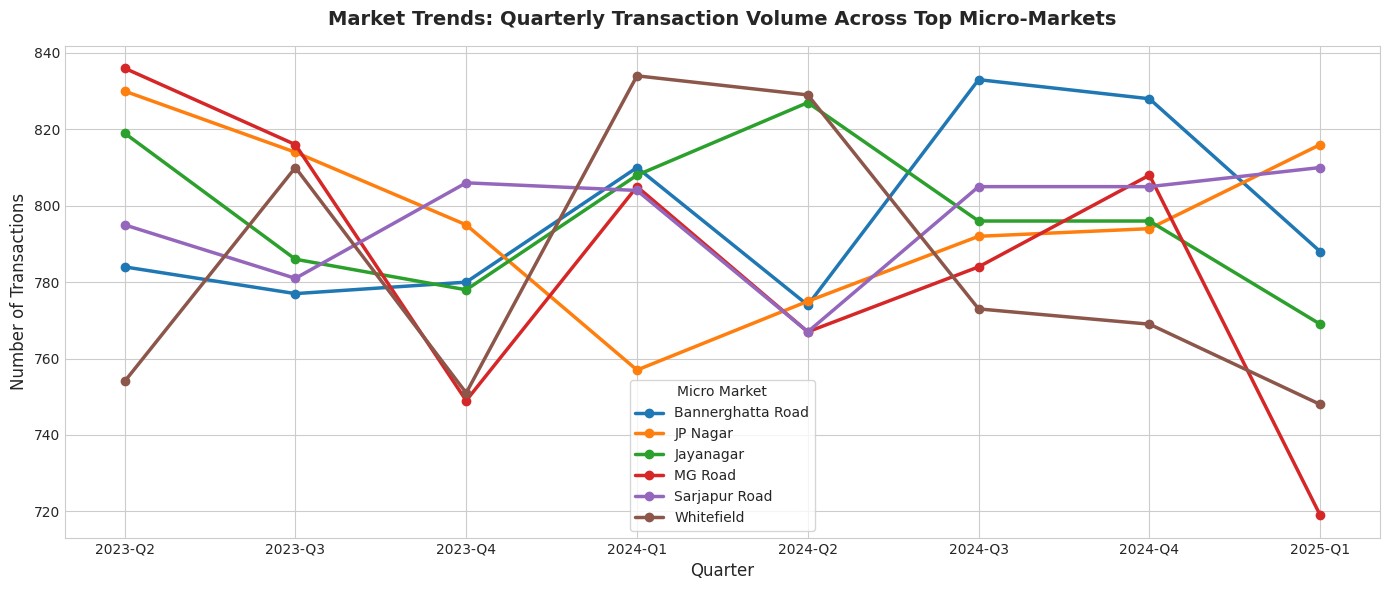

In [ ]:
# 1. Market Trends: Quarterly Transactions across Top Micro-Markets
top_markets = df_clean['Micro_Market'].value_counts().head(6).index.tolist()
df_quarterly_mkt = df_clean[df_clean['Micro_Market'].isin(top_markets)].groupby(['Quarter_Label', 'Micro_Market']).size().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
df_quarterly_mkt.plot(kind='line', marker='o', linewidth=2.5, ax=ax)
ax.set_title("Market Trends: Quarterly Transaction Volume Across Top Micro-Markets", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Quarter", fontsize=12)
ax.set_ylabel("Number of Transactions", fontsize=12)
ax.legend(title="Micro Market", frameon=True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/reports/01_market_trends_quarterly.png", dpi=300)
plt.show()

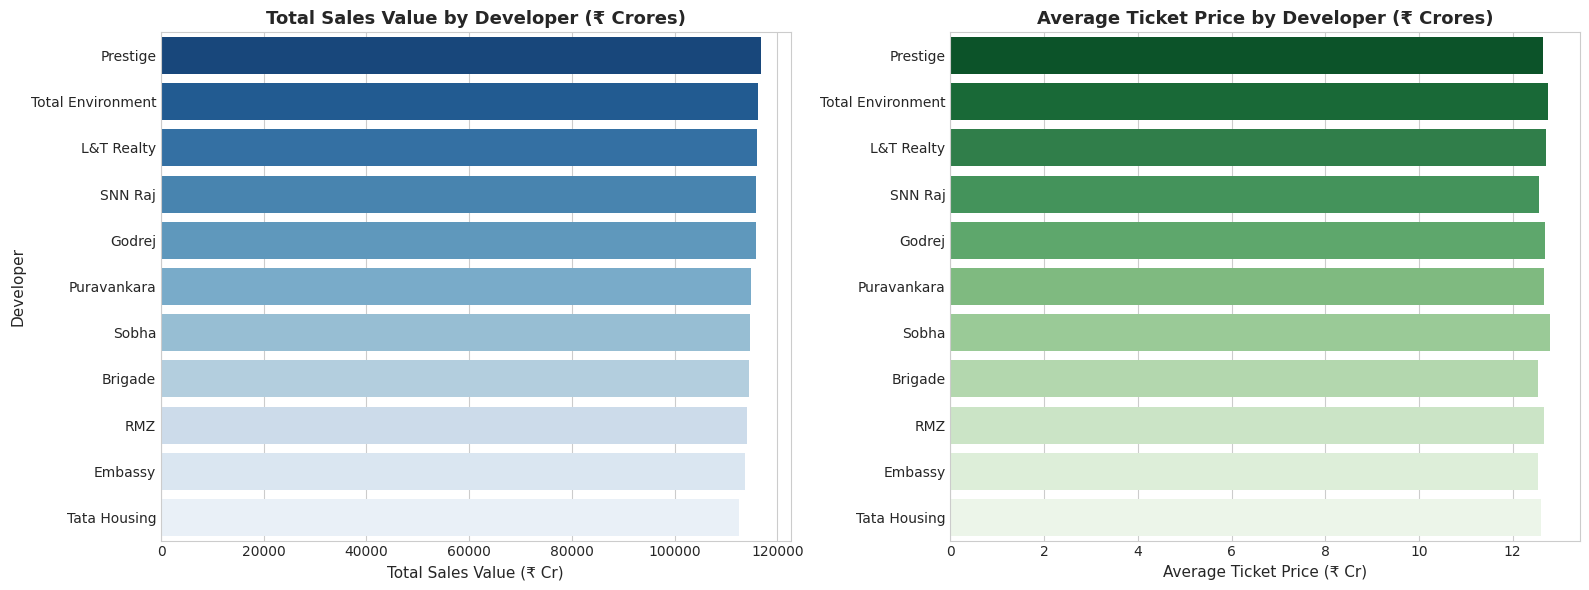

In [ ]:
# 2. Builder Performance: Total Ticket Value and Average Ticket Price
builder_perf = df_clean.groupby('Developer_Name').agg(
    Total_Value_Cr=('Ticket_Price_Cr', 'sum'),
    Avg_Price_Cr=('Ticket_Price_Cr', 'mean')
).sort_values(by='Total_Value_Cr', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=builder_perf['Total_Value_Cr'], y=builder_perf.index, hue=builder_perf.index, palette="Blues_r", legend=False, ax=ax1)
ax1.set_title("Total Sales Value by Developer (₹ Crores)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Total Sales Value (₹ Cr)", fontsize=11)
ax1.set_ylabel("Developer", fontsize=11)

sns.barplot(x=builder_perf['Avg_Price_Cr'], y=builder_perf.index, hue=builder_perf.index, palette="Greens_r", legend=False, ax=ax2)
ax2.set_title("Average Ticket Price by Developer (₹ Crores)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Average Ticket Price (₹ Cr)", fontsize=11)
ax2.set_ylabel("")

plt.tight_layout()
plt.savefig("outputs/reports/02_builder_performance.png", dpi=300)
plt.show()

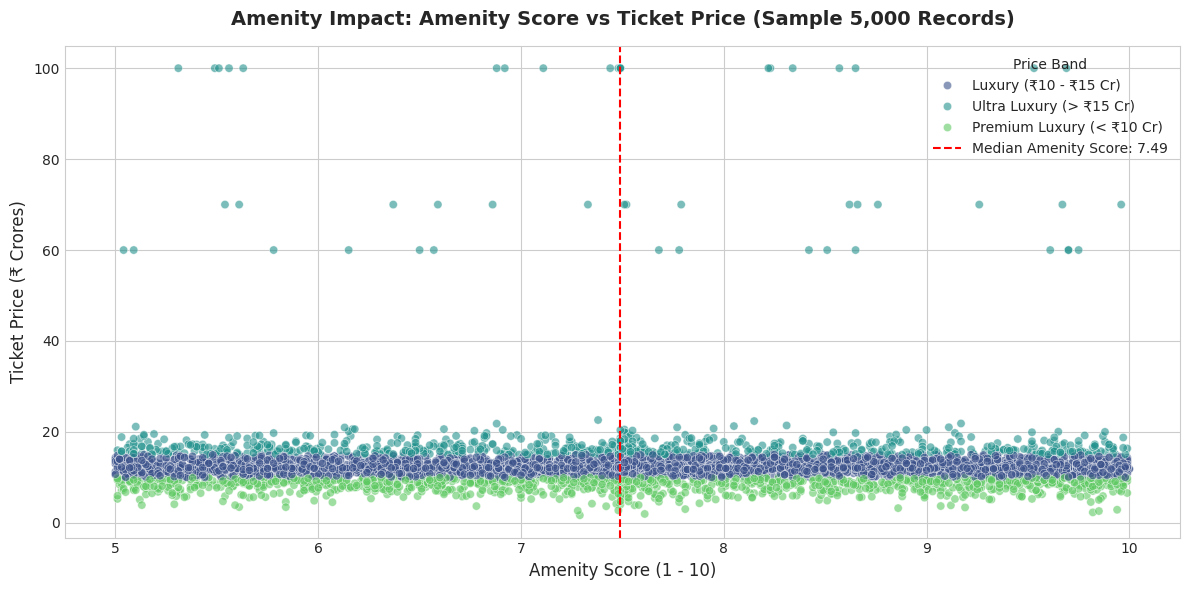

In [ ]:
# 3. Amenity Impact: Correlation with Ticket Price
fig, ax = plt.subplots(figsize=(12, 6))
sample_data = df_clean.sample(min(5000, len(df_clean)), random_state=42)
sns.scatterplot(
    data=sample_data,
    x='Amenity_Score',
    y='Ticket_Price_Cr',
    hue='Price_Band',
    alpha=0.6,
    palette='viridis',
    ax=ax
)
ax.set_title("Amenity Impact: Amenity Score vs Ticket Price (Sample 5,000 Records)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Amenity Score (1 - 10)", fontsize=12)
ax.set_ylabel("Ticket Price (₹ Crores)", fontsize=12)
ax.axvline(df_clean['Amenity_Score'].median(), color='red', linestyle='--', label=f"Median Amenity Score: {df_clean['Amenity_Score'].median():.2f}")
ax.legend(title="Price Band")
plt.tight_layout()
plt.savefig("outputs/reports/03_amenity_impact.png", dpi=300)
plt.show()

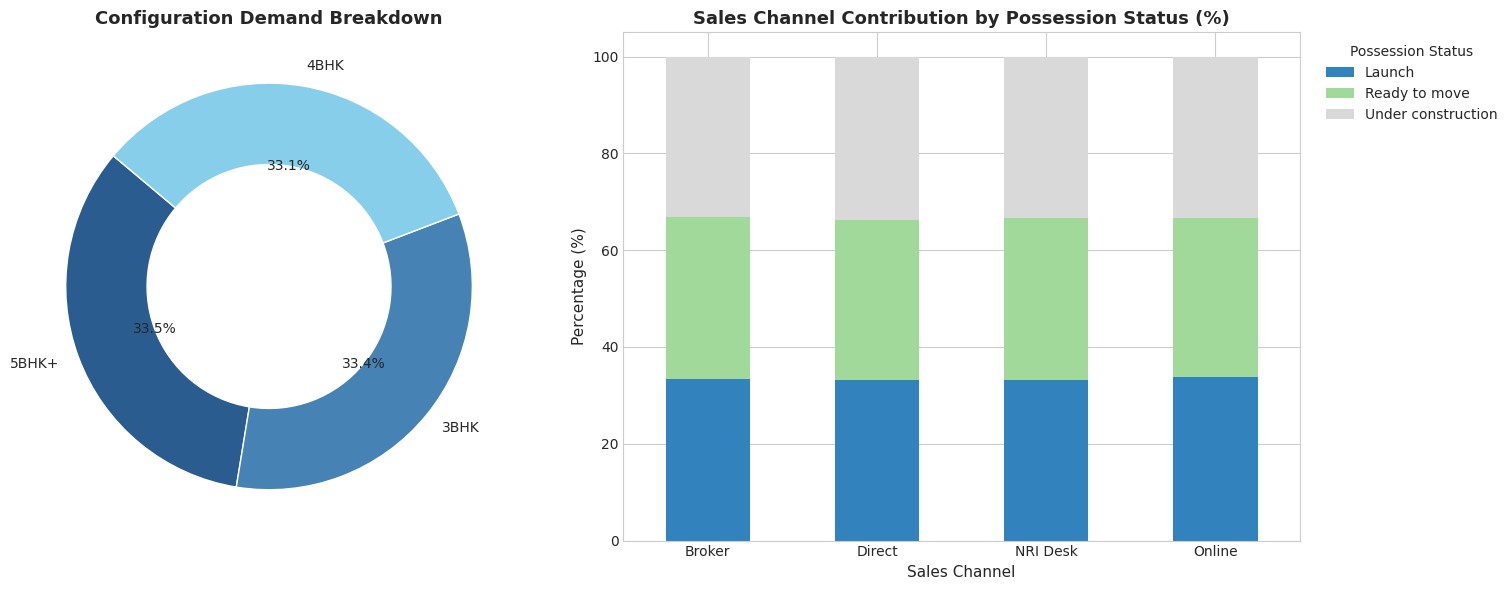

In [ ]:
# 4. Configuration Demand & 5. Sales Channel Efficiency
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Configuration Donut Chart
config_counts = df_clean['Configuration'].value_counts()
colors = ['#2b5c8f', '#4682b4', '#87ceeb']
ax1.pie(config_counts, labels=config_counts.index, autopct='%1.1f%%', startangle=140,
        colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'))
ax1.set_title("Configuration Demand Breakdown", fontsize=13, fontweight='bold')

# Sales Channel Contribution by Possession Status
channel_possession = pd.crosstab(df_clean['Sales_Channel'], df_clean['Possession_Status'], normalize='index') * 100
channel_possession.plot(kind='bar', stacked=True, colormap='tab20c', ax=ax2)
ax2.set_title("Sales Channel Contribution by Possession Status (%)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Sales Channel", fontsize=11)
ax2.set_ylabel("Percentage (%)", fontsize=11)
plt.xticks(rotation=0)
ax2.legend(title="Possession Status", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig("outputs/reports/04_configuration_and_channels.png", dpi=300)
plt.show()

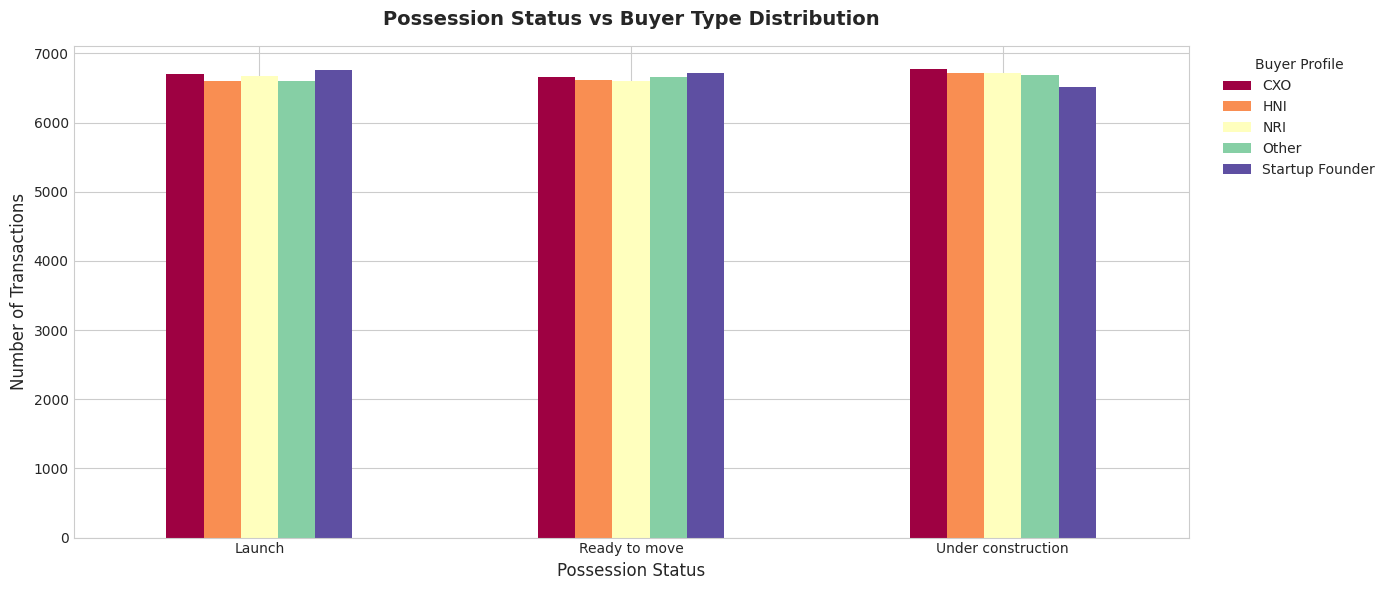

In [ ]:
# 6. Possession Status vs Buyer Type
fig, ax = plt.subplots(figsize=(14, 6))
buyer_possession = pd.crosstab(df_clean['Possession_Status'], df_clean['Buyer_Type'])
buyer_possession.plot(kind='bar', ax=ax, colormap='Spectral')
ax.set_title("Possession Status vs Buyer Type Distribution", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Possession Status", fontsize=12)
ax.set_ylabel("Number of Transactions", fontsize=12)
plt.xticks(rotation=0)
ax.legend(title="Buyer Profile", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("outputs/reports/05_possession_vs_buyer.png", dpi=300)
plt.show()

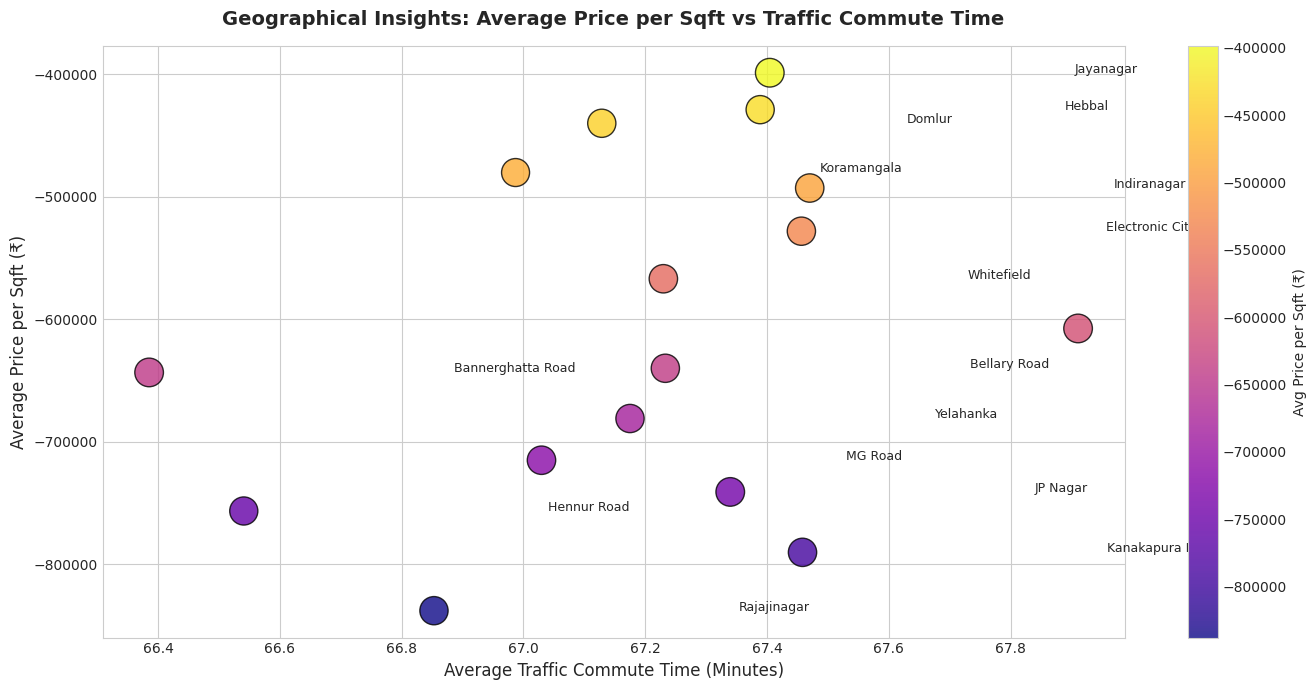

In [ ]:
# 7. Geographical Insights: Average Price per Sqft vs Commute Traffic Time
mkt_geo = df_clean.groupby('Micro_Market').agg(
    Avg_Price_Sqft=('Price_per_Sqft', 'mean'),
    Avg_Traffic=('Avg_Traffic_Time_Min', 'mean'),
    Total_Sales=('Property_ID', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
scatter = ax.scatter(
    mkt_geo['Avg_Traffic'],
    mkt_geo['Avg_Price_Sqft'],
    s=mkt_geo['Total_Sales'] / 15,
    c=mkt_geo['Avg_Price_Sqft'],
    cmap='plasma',
    alpha=0.8,
    edgecolors='black'
)
for _, row in mkt_geo.iterrows():
    ax.annotate(row['Micro_Market'], (row['Avg_Traffic'] + 0.5, row['Avg_Price_Sqft'] + 100), fontsize=9)

ax.set_title("Geographical Insights: Average Price per Sqft vs Traffic Commute Time", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Average Traffic Commute Time (Minutes)", fontsize=12)
ax.set_ylabel("Average Price per Sqft (₹)", fontsize=12)
fig.colorbar(scatter, ax=ax, label="Avg Price per Sqft (₹)")
plt.tight_layout()
plt.savefig("outputs/reports/06_geographical_insights.png", dpi=300)
plt.show()